In [7]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [8]:
# =========================
# Load dataset splits
# =========================
DATA_PATH = "../../Datasets/Norway InfiniumPurify Dataset Splits"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
X_test  = pd.read_csv(f"{DATA_PATH}/X_test.csv")
Y_train = pd.read_csv(f"{DATA_PATH}/Y_train.csv")
Y_test  = pd.read_csv(f"{DATA_PATH}/Y_test.csv")

# Ensure y is 1D
y_train = np.ravel(Y_train)
y_test  = np.ravel(Y_test)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((218, 21101), (54, 21101), (218,), (54,))


Calculating SHAP values...
SHAP values shape: (54, 500, 5)
Selected features: 500

=== Overall Top 10 Features ===
      Feature  MeanAbsSHAP_MaxAcrossSubtypes
468     CST11                       0.013944
6      TMEM26                       0.013122
365   MIR520D                       0.010871
461  HIST1H1A                       0.010722
105    KCNJ16                       0.009717
459      CFL2                       0.009485
83      KRT17                       0.009383
62    TMPRSS5                       0.008591
73      PRDM8                       0.008093
496   TMEM207                       0.007896


C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


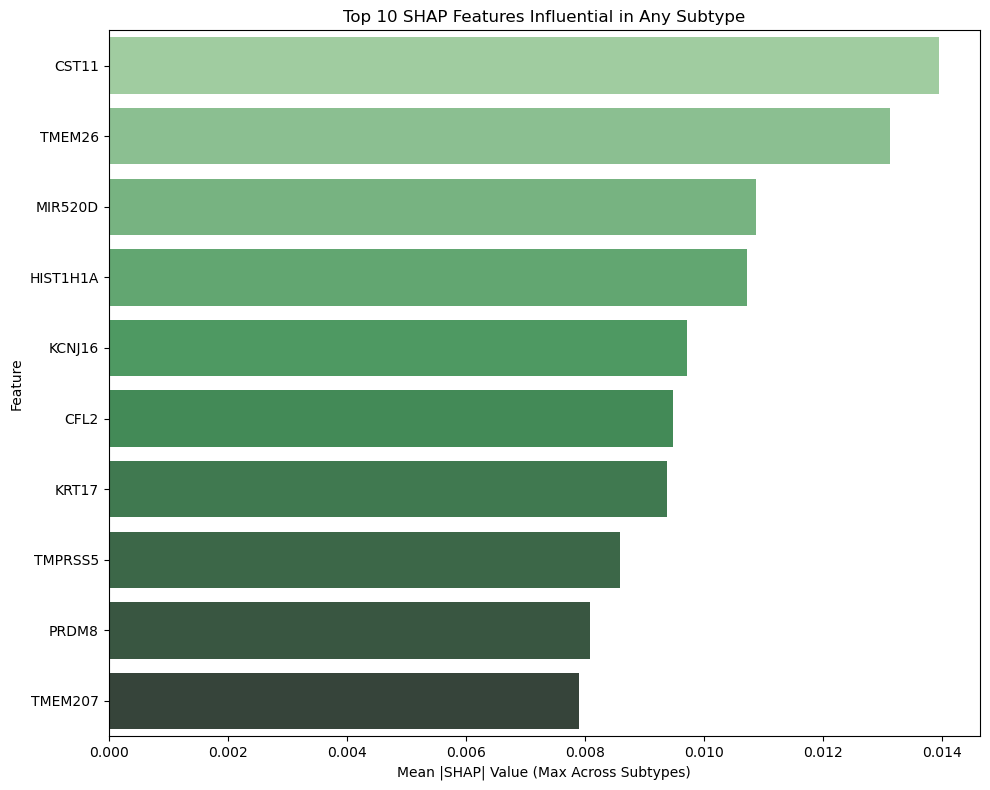

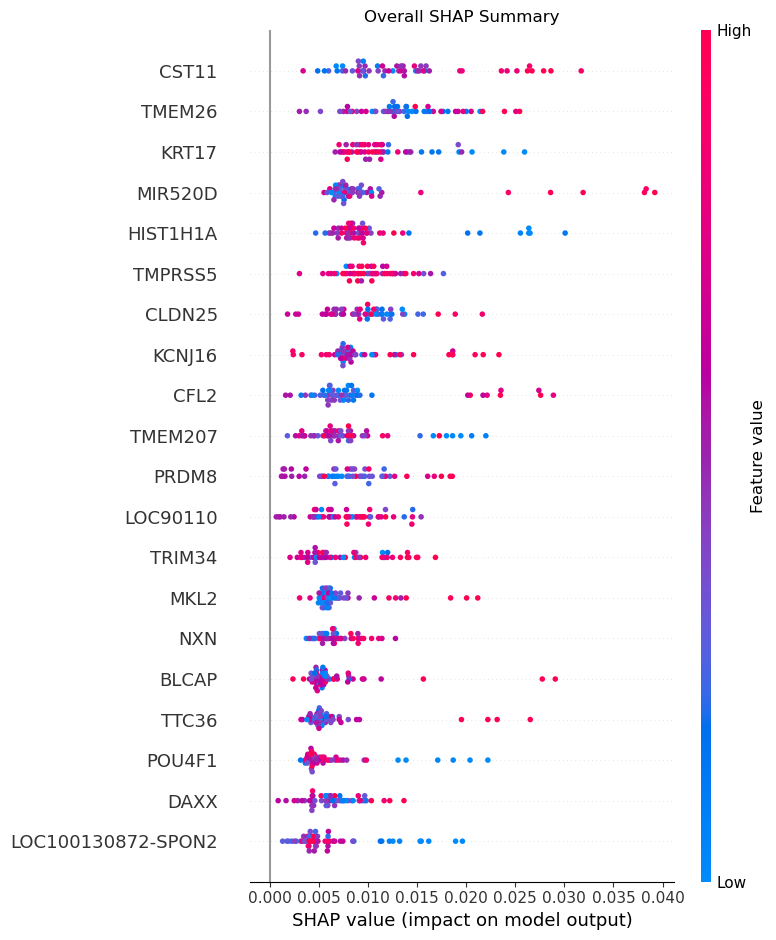


Subtype 1: Basal
      Feature  MeanAbsSHAP
365   MIR520D     0.010871
461  HIST1H1A     0.010722
105    KCNJ16     0.009717
83      KRT17     0.008912
146      MKL2     0.007288
47      TTC36     0.006718
10      BLCAP     0.006715
154    POU4F1     0.006508
38    CYSLTR1     0.006081
480     REP15     0.005648


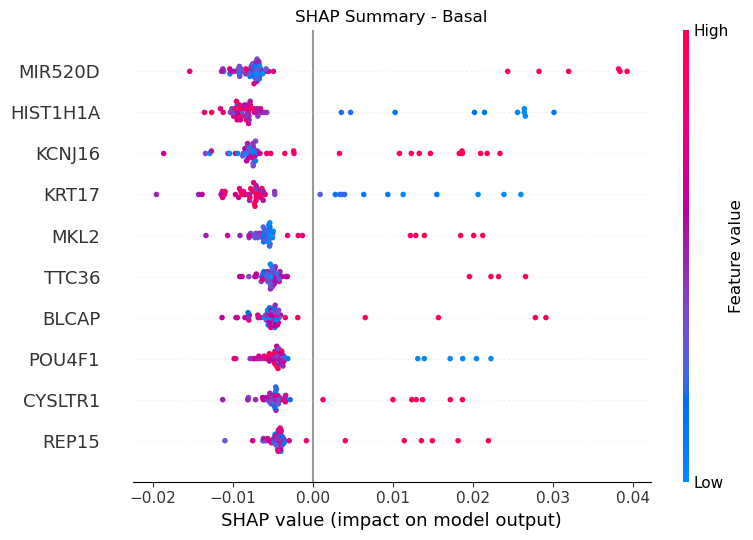

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


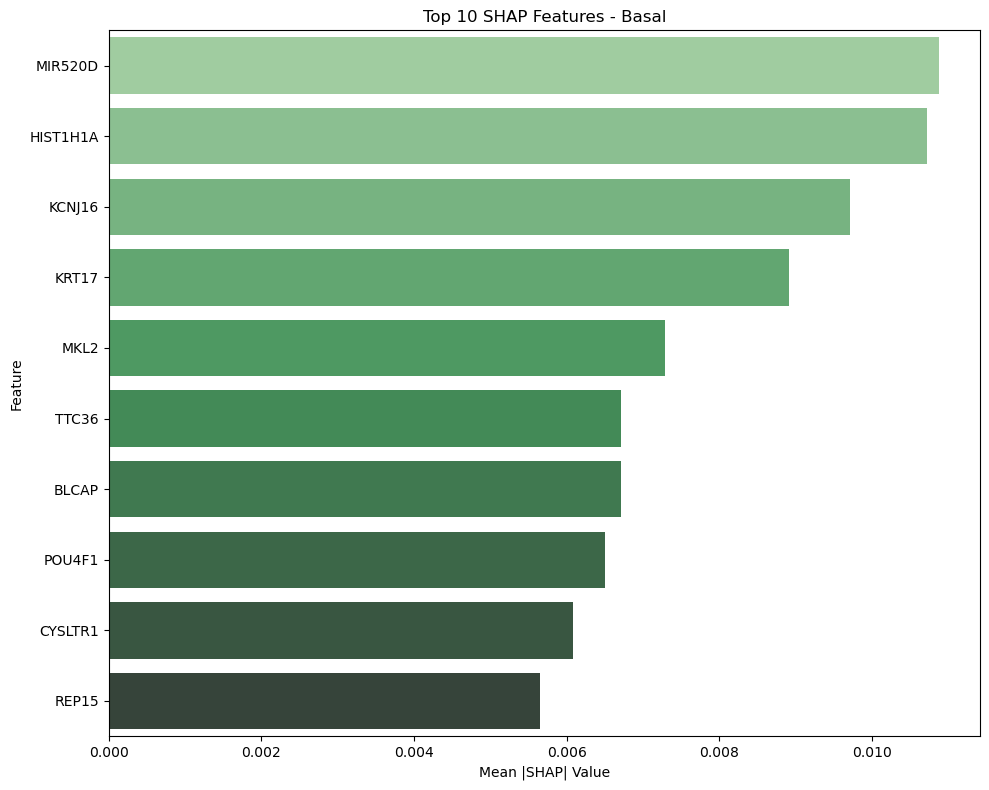


Subtype 2: Her2
                Feature  MeanAbsSHAP
6                TMEM26     0.013122
459                CFL2     0.009485
73                PRDM8     0.008093
353            LOC90110     0.007706
101            KIAA0754     0.006310
55   LOC100130872-SPON2     0.006306
3                  DAXX     0.006294
69              NEUROD2     0.006003
365             MIR520D     0.005865
86             MIR365-2     0.005806


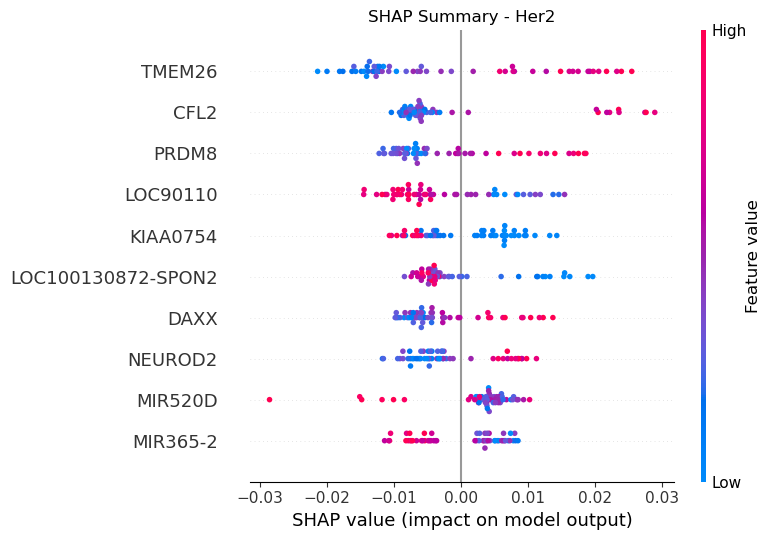

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


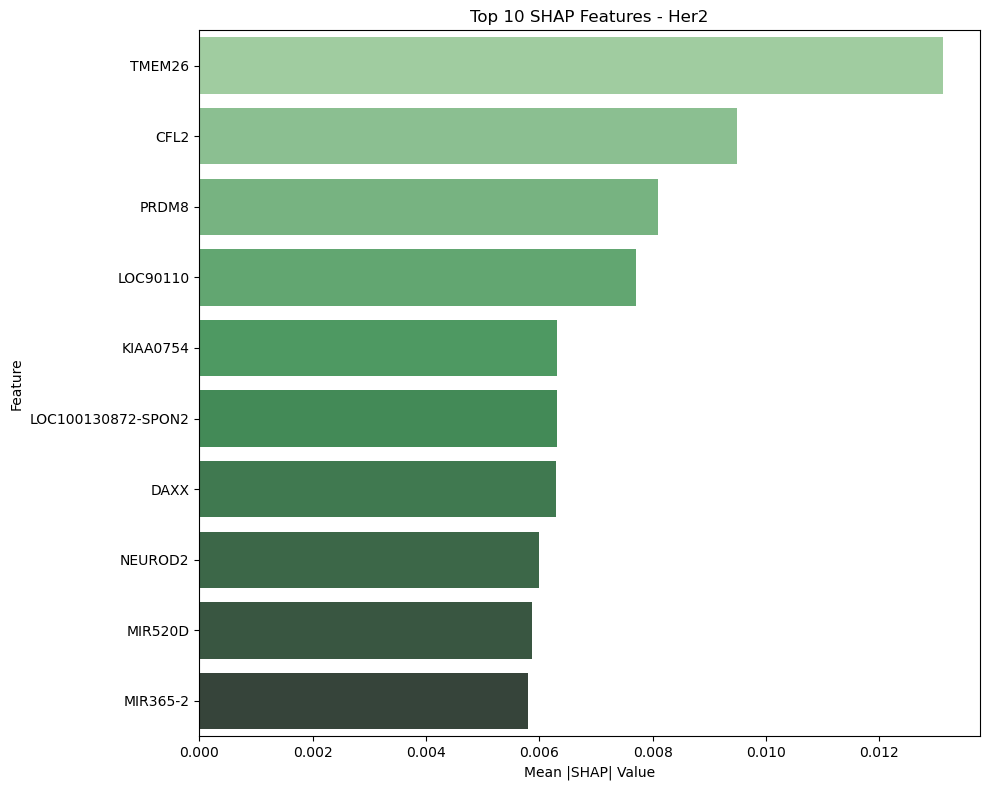


Subtype 3: LumA
     Feature  MeanAbsSHAP
125   TRIM34     0.007317
165   CLDN25     0.006843
83     KRT17     0.006594
6     TMEM26     0.006060
496  TMEM207     0.005220
11       NXN     0.005163
3       DAXX     0.004953
26   SLC43A2     0.004840
105   KCNJ16     0.004701
463   MICAL1     0.004580


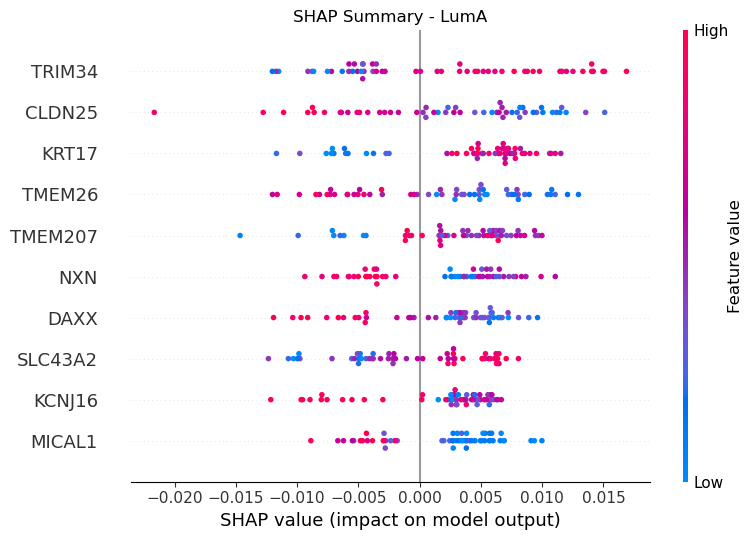

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


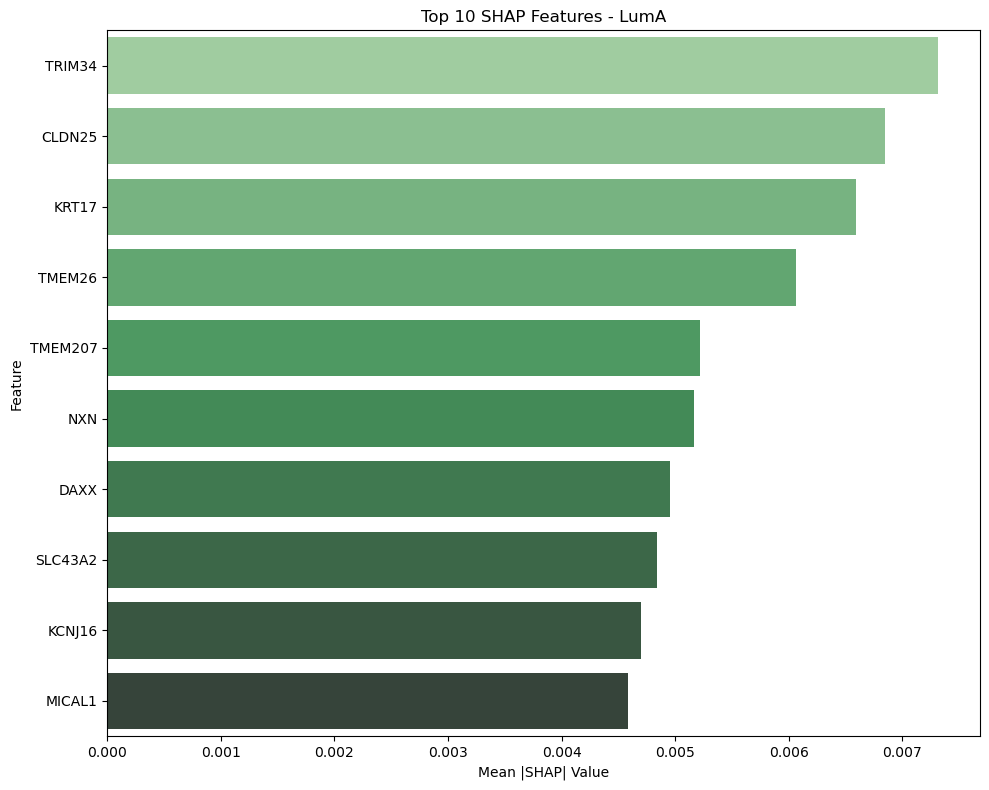


Subtype 4: LumB
     Feature  MeanAbsSHAP
468    CST11     0.013944
6     TMEM26     0.010549
62   TMPRSS5     0.008591
496  TMEM207     0.007896
165   CLDN25     0.007515
83     KRT17     0.006410
11       NXN     0.004578
365  MIR520D     0.004464
106     MSMP     0.004308
320   OR52M1     0.004224


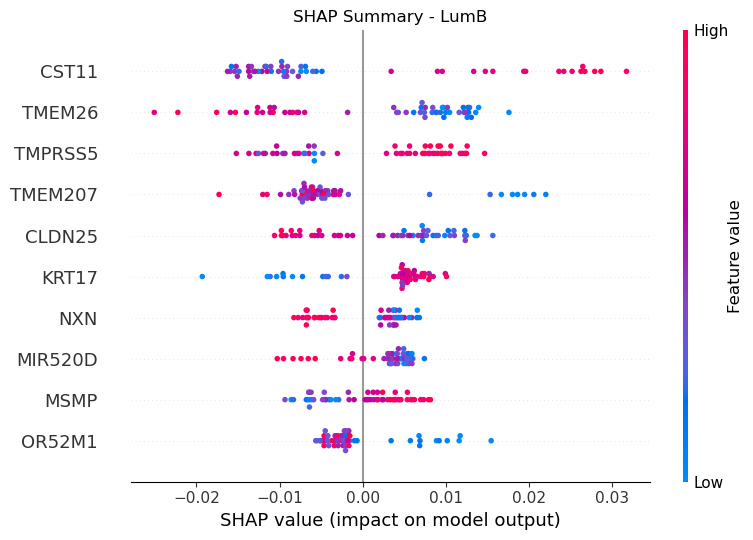

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


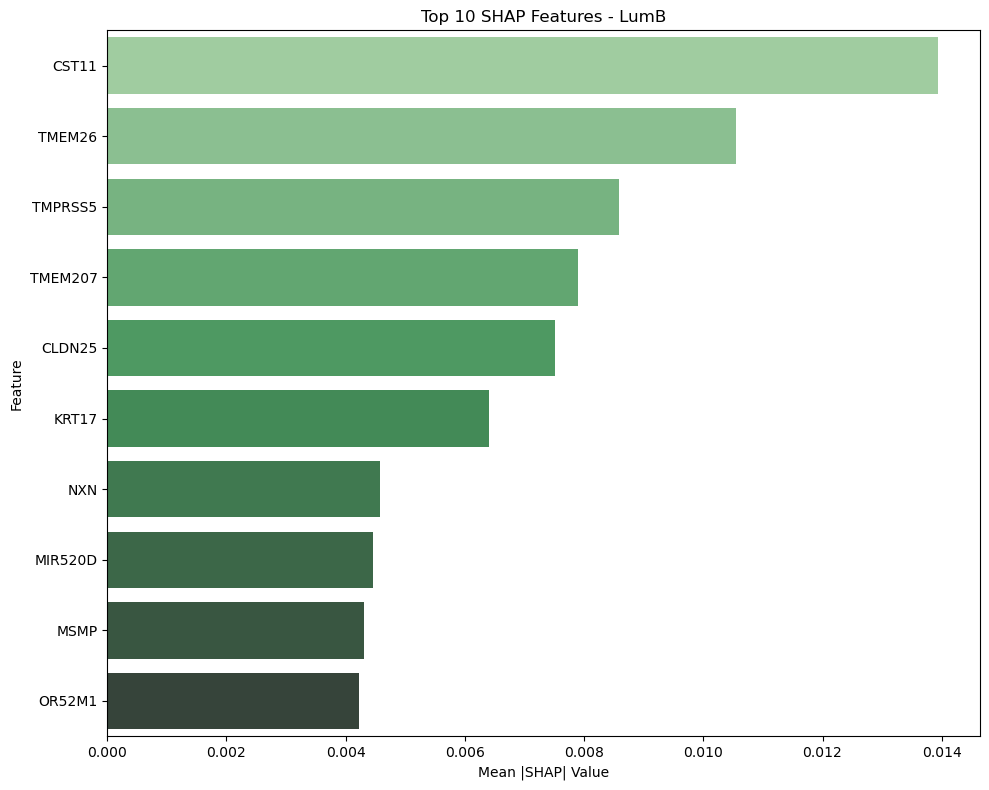


Subtype 5: Normal
     Feature  MeanAbsSHAP
83     KRT17     0.009383
62   TMPRSS5     0.008245
165   CLDN25     0.007605
365  MIR520D     0.005404
11       NXN     0.005385
106     MSMP     0.005021
488  SNORA56     0.004817
208    ACMSD     0.004279
400    LYRM4     0.003948
468    CST11     0.003925


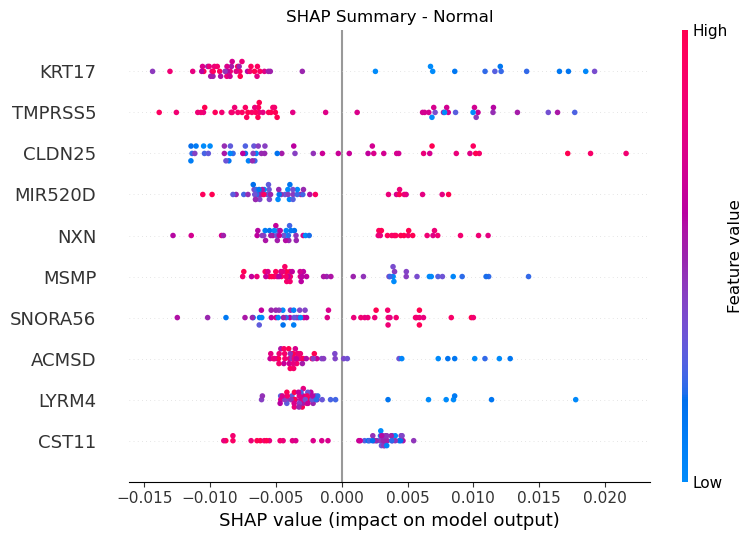

C:\Users\Roooiz\AppData\Local\Temp\ipykernel_37268\2427387025.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


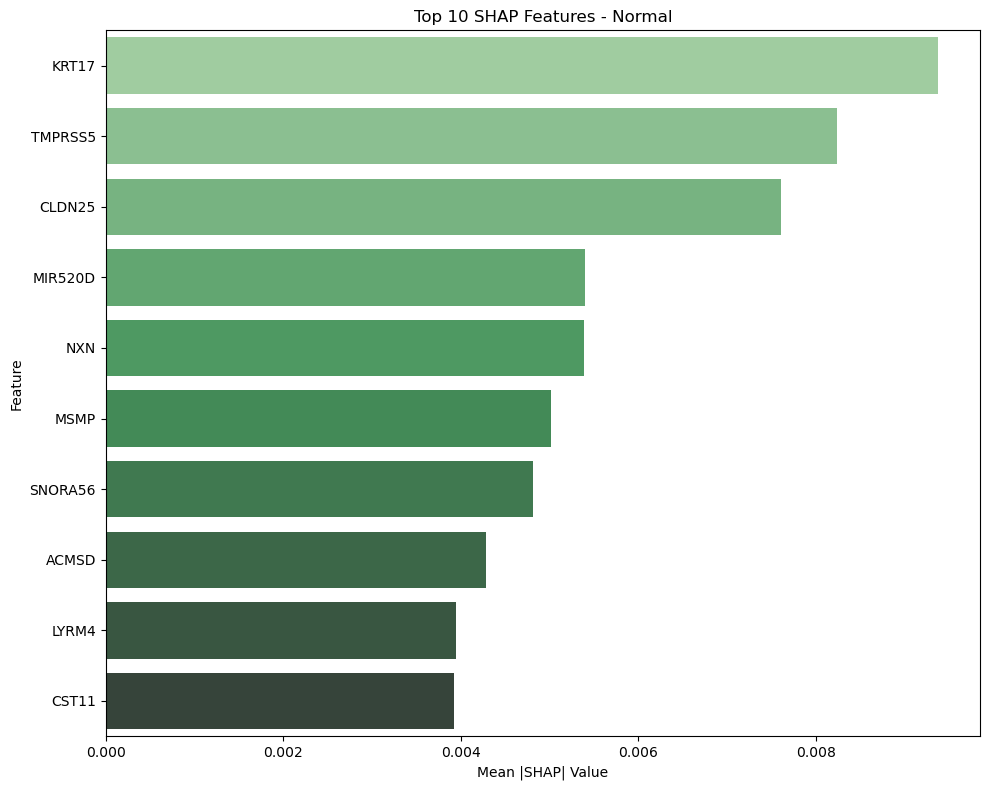


SHAP analysis complete — both overall and per-subtype results generated.


In [9]:
# --- Choose your model ---
best_model_rfe = joblib.load("PKL/RF_Norway_IP_SMOTE_RFE.pkl")
pipeline_model = best_model_rfe  # or best_model_no_rfe

# --- Extract components ---
rfe = pipeline_model.named_steps['rfe']
rf_model = pipeline_model.named_steps['rf']
scaler = pipeline_model.named_steps['scaler']

# --- Prepare data ---
selected_mask = rfe.support_  # which features RFE kept
selected_features = np.array(X_test.columns)[selected_mask]

# Scale test set
X_test_scaled = scaler.transform(X_test)
X_test_selected = X_test_scaled[:, selected_mask]

# --- Create SHAP explainer ---
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_selected)

# Handle multi-class output
if isinstance(shap_values, list):  # one array per class
    shap_values = np.stack(shap_values, axis=2)  # shape: (samples, features, classes)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Selected features: {len(selected_features)}")

# ====================================================
# 1. OVERALL (across all classes)
# ====================================================
mean_abs_shap_anywhere = np.abs(shap_values).mean(axis=0).max(axis=1)

shap_importances_overall = pd.DataFrame({
    "Feature": selected_features,
    "MeanAbsSHAP_MaxAcrossSubtypes": mean_abs_shap_anywhere
}).sort_values(by="MeanAbsSHAP_MaxAcrossSubtypes", ascending=False)

print("\n=== Overall Top 10 Features ===")
print(shap_importances_overall.head(10))

# Bar plot
plt.figure(figsize=(10, 8))
sns.barplot(
    data=shap_importances_overall.head(10),
    x="MeanAbsSHAP_MaxAcrossSubtypes",
    y="Feature",
    palette="Greens_d"
)
plt.title("Top 10 SHAP Features Influential in Any Subtype")
plt.xlabel("Mean |SHAP| Value (Max Across Subtypes)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Overall SHAP summary
shap_values_overall = np.abs(shap_values).max(axis=2)  # max per sample across classes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_overall, X_test_selected,
    feature_names=selected_features,
    max_display=20, show=False
)
plt.title("Overall SHAP Summary")
plt.tight_layout()
plt.show()

# ====================================================
# 2. PER-CLASS (each subtype separately)
# ====================================================
class_names = rf_model.classes_
for class_idx, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"Subtype {class_idx + 1}: {class_name}")
    
    shap_values_class = shap_values[:, :, class_idx]
    class_mean_abs_shap = np.abs(shap_values_class).mean(axis=0)
    
    shap_importances_class = pd.DataFrame({
        "Feature": selected_features,
        "MeanAbsSHAP": class_mean_abs_shap
    }).sort_values(by="MeanAbsSHAP", ascending=False)
    
    print(shap_importances_class.head(10))
    
    # SHAP summary plot per class
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values_class, X_test_selected,
        feature_names=selected_features,
        max_display=10, show=False
    )
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.show()
    
    # Bar plot top 10 per class
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=shap_importances_class.head(10),
        x="MeanAbsSHAP",
        y="Feature",
        palette="Greens_d"
    )
    plt.title(f"Top 10 SHAP Features - {class_name}")
    plt.xlabel("Mean |SHAP| Value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

print("\nSHAP analysis complete — both overall and per-subtype results generated.")